**TEAM CONTRIBUTIONS**
1. Balanjani Janjanam (UID: U01131435)
Responsible for Data Exploration, Visualization and EDA summary
2. Vishnu Vardhan Reddy Dandu (UID: U01126178)
Responsible for ML Pipeline implementation and preprocessing
3. Shreya Chowgani (UID: U01122180)
Responsible for Advanced Modeling, tuning and evaluation
4. Harshavardhan Reddy Boggula (UID: U01109555)
Responsible for Model Explainability (SHAP) and Presentation

In [ ]:
!pip install -q imbalanced-learn xgboost lightgbm shap optuna joblib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.8 MB/s eta 0:00:00


Import Libraries & Read Dataset

**Handled by: Balanjani Janjanam (EDA & Visualization Lead)**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())


(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


Check data types, missing values and class balance.

In [ ]:
df.info()
print("\nMissing values:", df.isnull().sum().sum())

print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nClass proportion:")
print(df['Class'].value_counts(normalize=True).round(5))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Basic Statistics

In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


**EDA (Exploratory Data Analysis)**
**Handled by: Balanjani Janjanam**

Class distribution

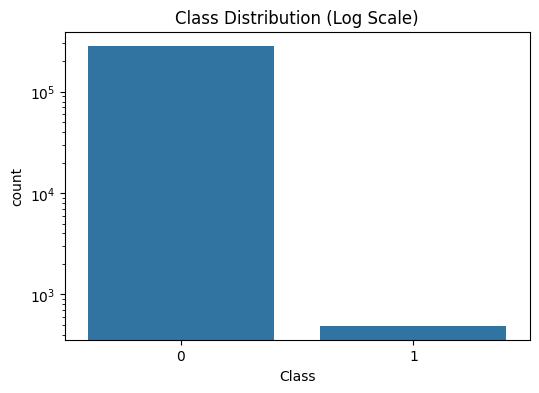

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.yscale('log')
plt.title('Class Distribution (Log Scale)')
plt.show()

Transaction Amount distribution

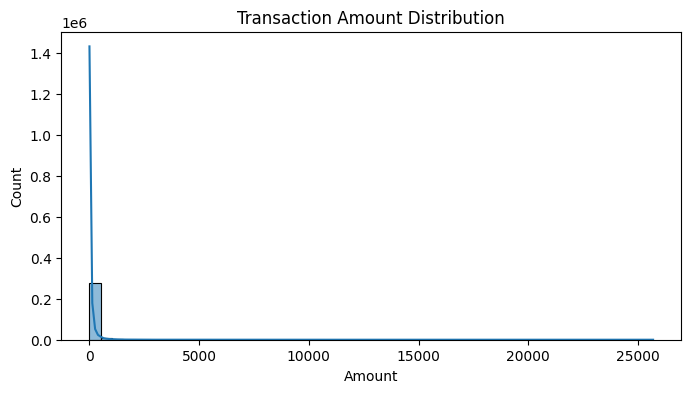

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()


Transaction Time distribution

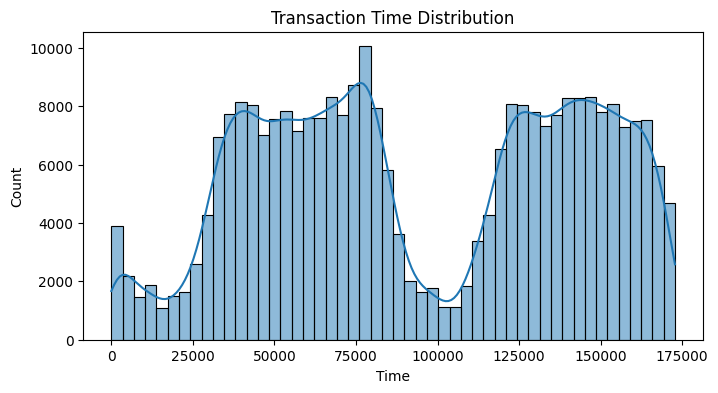

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Transaction Time Distribution')
plt.show()


**Train-Test Split and Data Preparation**

**Handled by: Vishnu Vardhan Reddy Dandu (Pipeline & Implementation Lead)**

We will keep 80% for training and 20% for testing.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print("Fraud rate in training:", round(y_train.mean(), 5))
print("Fraud rate in testing:", round(y_test.mean(), 5))


(227845, 30) (56962, 30)
Fraud rate in training: 0.00173
Fraud rate in testing: 0.00172


**Save Clean Data**

In [ ]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


**Train the Baseline Logistic Regression Model**

**Handled by: Vishnu Vardhan Reddy Dandu**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline to scale data + train logistic regression
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(
        class_weight='balanced',   # handles class imbalance
        random_state=42,
        max_iter=500
    ))
])

# Fit model on training data
log_reg_model.fit(X_train, y_train)

# Predict on test data
y_pred = log_reg_model.predict(X_test)
y_pred_prob = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully.")
print(f"Predictions shape: {y_pred.shape}")
print(f"First 10 predictions: {y_pred[:10]}")


Logistic Regression model trained successfully.
Predictions shape: (56962,)
First 10 predictions: [0 0 0 0 1 0 0 0 0 0]


**Evaluate Logistic Regression Model**

**Handled by: Shreya Chowgani (Model Evaluation Lead)**

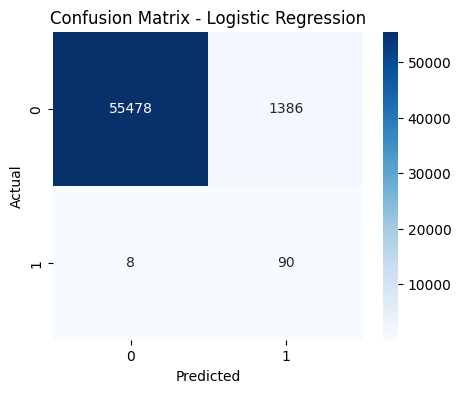

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962

ROC-AUC Score: 0.9721
Precision-Recall AUC: 0.7639


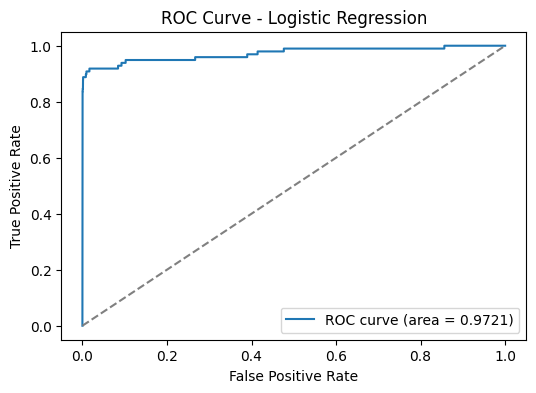

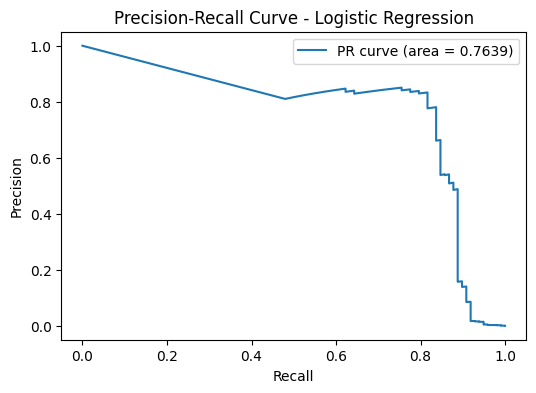

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"PR curve (area = {pr_auc:.4f})")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


Interpretation

Our baseline Logistic Regression achieved strong recall (91.8%) and high AUC (0.97).
Although precision is low (6%), this trade-off is expected in fraud detection, where identifying fraudulent cases is more important than minimizing false alarms.
These results serve as a benchmark for comparing advanced models like Random Forest, XGBoost and LightGBM.

**Advanced Model 1: Random Forest**

**Handled by: Shreya Chowgani**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,
    class_weight='balanced', # handle imbalance
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")
print(f"Predictions shape: {y_pred_rf.shape}")
print(f"First 10 predictions: {y_pred_rf[:10]}")


Random Forest model trained successfully.
Predictions shape: (56962,)
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


**Evaluate Random Forest Classifier**

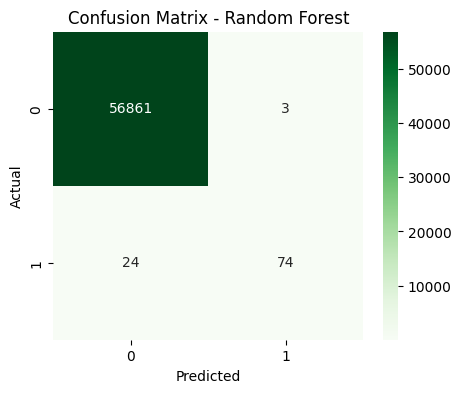

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0.9227     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC Score: 0.9572
Precision-Recall AUC: 0.8623


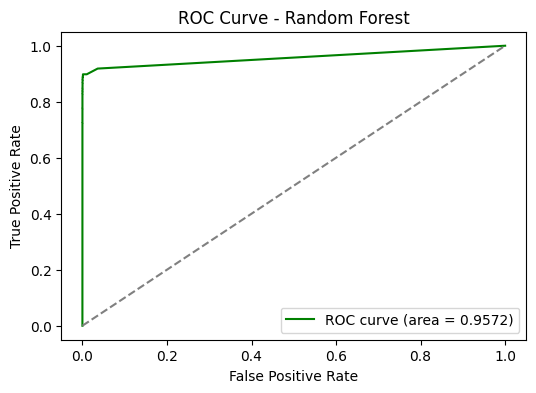

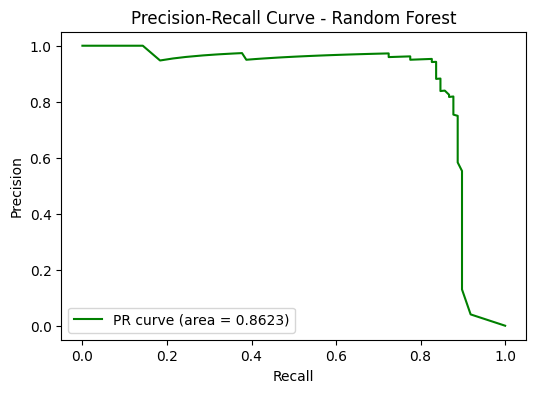

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, digits=4))

# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_pred_prob_rf)
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")

# Precision-Recall AUC
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_prob_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
print(f"Precision-Recall AUC: {pr_auc_rf:.4f}")

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"ROC curve (area = {roc_auc_rf:.4f})", color='green')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(6,4))
plt.plot(recall_rf, precision_rf, label=f"PR curve (area = {pr_auc_rf:.4f})", color='green')
plt.title("Precision-Recall Curve - Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


Interpretation

Random Forest achieved a strong balance between recall and precision.
While Logistic Regression focused more on maximizing recall, Random Forest offers much higher precision and overall accuracy.
This trade-off makes Random Forest a more stable model for deployment, reducing false alarms while still catching most frauds.

**Advanced Model 2: XGBoost**

**Handled by: Shreya Chowgani (Modeling) & Vishnu (Pipeline Integration)**

In [ ]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,          # number of trees
    learning_rate=0.1,         # step size
    max_depth=6,               # depth of trees
    subsample=0.8,             # row sampling
    colsample_bytree=0.8,      # feature sampling
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]), # handle imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost model trained successfully.")
print(f"Predictions shape: {y_pred_xgb.shape}")
print(f"First 10 predictions: {y_pred_xgb[:10]}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:01:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully.
Predictions shape: (56962,)
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


**Evaluate XGBoost Model**

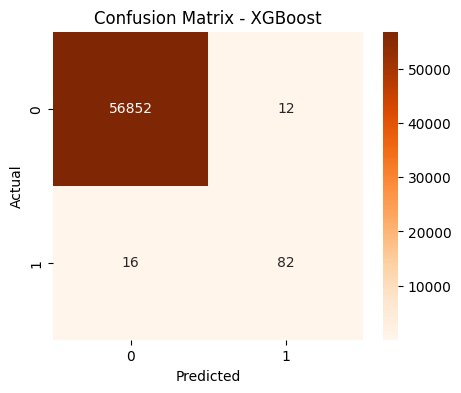

Classification Report - XGBoost:
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8723    0.8367    0.8542        98

    accuracy                         0.9995     56962
   macro avg     0.9360    0.9183    0.9270     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC Score: 0.9737
Precision-Recall AUC: 0.8798


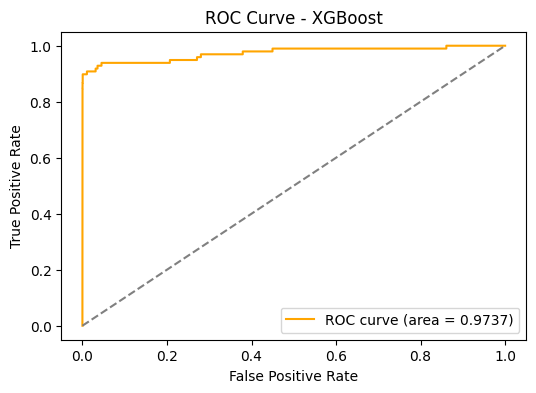

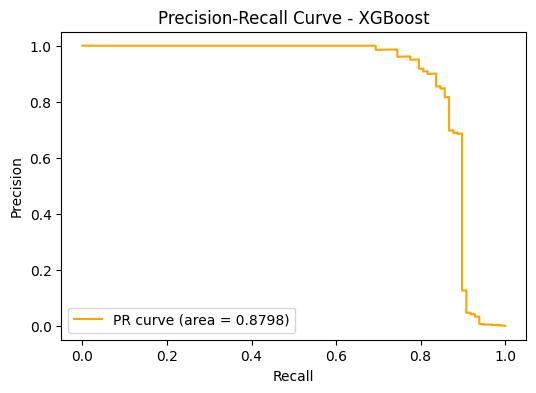

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb, digits=4))

# ROC-AUC
roc_auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")

# Precision-Recall AUC
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_prob_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)
print(f"Precision-Recall AUC: {pr_auc_xgb:.4f}")

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_prob_xgb)
plt.figure(figsize=(6,4))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC curve (area = {roc_auc_xgb:.4f})", color='orange')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title("ROC Curve - XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(6,4))
plt.plot(recall_xgb, precision_xgb, label=f"PR curve (area = {pr_auc_xgb:.4f})", color='orange')
plt.title("Precision-Recall Curve - XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


This model outperforms both Logistic Regression and Random Forest overall.

**Feature Importance & Explainability (using SHAP)**

**Handled by: Harshavardhan Reddy Boggula (Model Interpretation & Presentation)**

We will use SHAP (SHapley Additive exPlanations) to understand which features (PCA components + Amount + Time) most influence fraud detection decisions.

PermutationExplainer explainer: 501it [02:27,  3.25it/s]
/tmp/ipython-input-1847660464.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20)


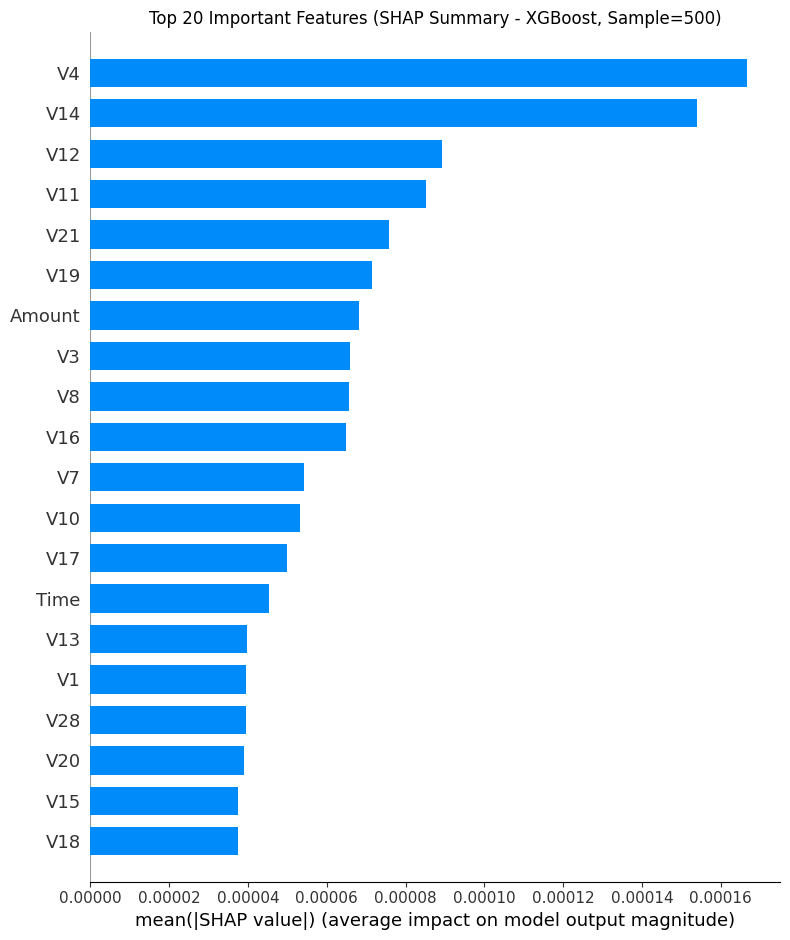

/tmp/ipython-input-1847660464.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, max_display=20)


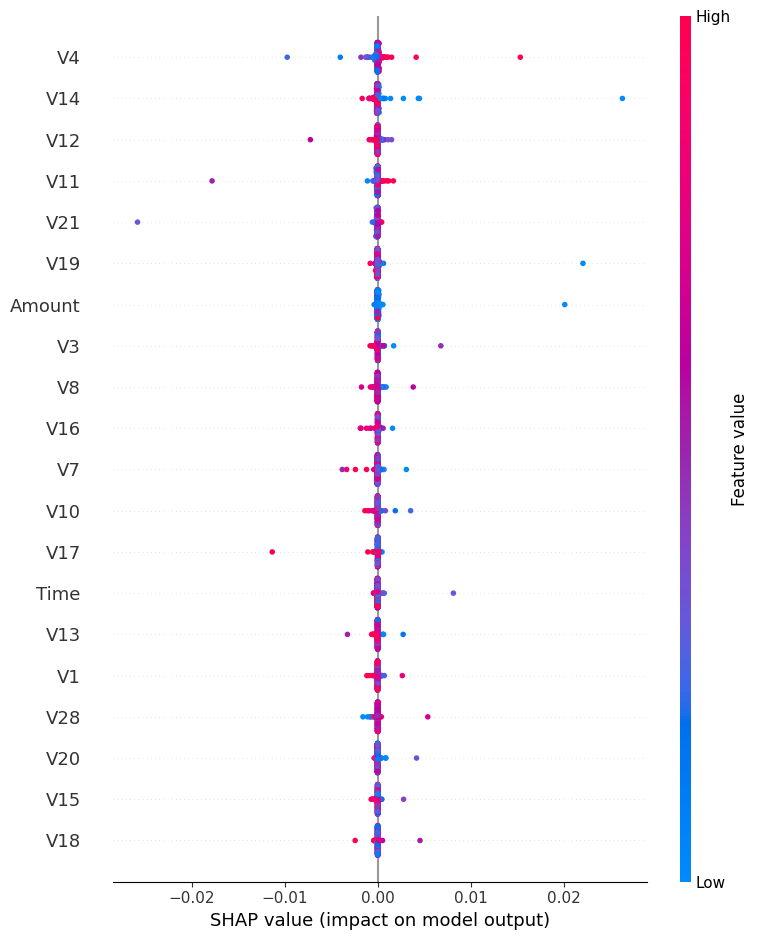

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Use a smaller random sample for faster SHAP computation
X_sample = X_test.sample(500, random_state=42)

predict_fn = lambda x: xgb_model.predict_proba(x)[:, 1]
explainer = shap.Explainer(predict_fn, X_sample)
shap_values = explainer(X_sample)

# Feature importance bar plot
plt.title("Top 20 Important Features (SHAP Summary - XGBoost, Sample=500)")
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20)

# Detailed summary plot (beeswarm)
shap.summary_plot(shap_values, X_sample, max_display=20)
